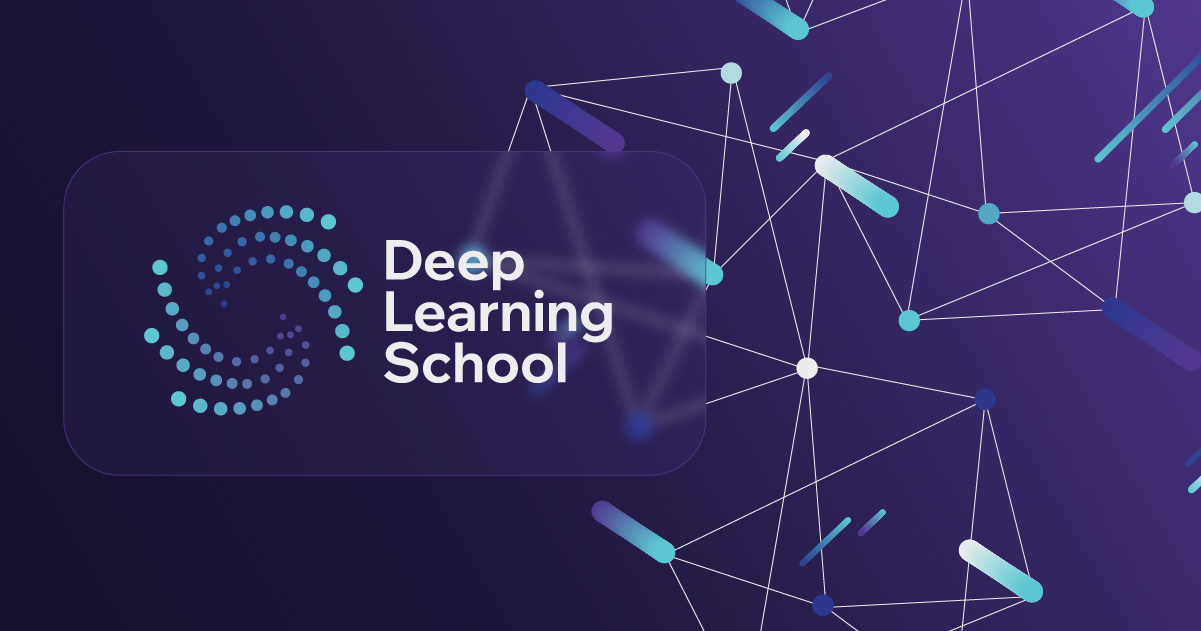


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [20]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [ ]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [ ]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

100%|██████████| 6.49M/6.49M [00:00<00:00, 42.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/averkij/lfw-attributes/versions/1


In [ ]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/root/.cache/kagglehub/datasets/averkij/lfw-attributes/versions/1/lfw_attributes.txt"

In [ ]:
df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)

In [ ]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [ ]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [ ]:
from sklearn.model_selection import train_test_split

train_photos, val_photos, train_attrs, val_attrs = train_test_split(images, attrs,
                                                                    train_size=0.9, shuffle=False)
# <тут Ваш код>

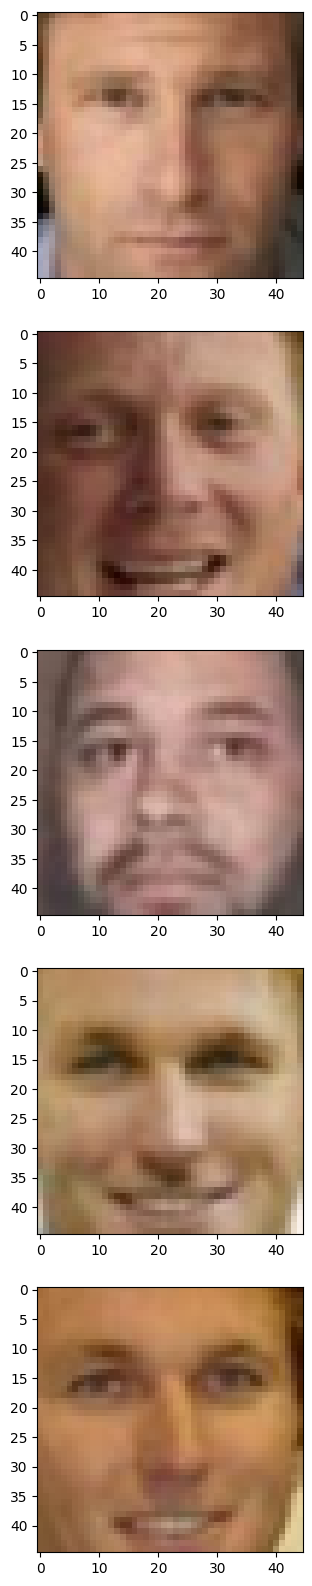

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 20))
for i in range(5):
  plt.subplot(5, 1, i+1)
  plt.imshow(train_photos[i])

Перевод в тензор и нормализация:

In [ ]:
train_photos_t = torch.tensor(train_photos, dtype=torch.float32) / 255.0 # YOUR CODE GOES HERE
val_photos_t = torch.tensor(val_photos, dtype=torch.float32) / 255.0 # YOUR CODE GOES HERE

In [ ]:
train_photos_t.shape # Формат: (batch, height, width, channels) - это channels last

torch.Size([11828, 45, 45, 3])

Нужно преобразовать в формат PyTorch (batch, channels, height, width):

In [ ]:
train_photos_t = train_photos_t.permute(0, 3, 1, 2)

In [ ]:
train_photos_t.shape

torch.Size([11828, 3, 45, 45])

In [ ]:
val_photos_t = val_photos_t.permute(0, 3, 1, 2)

In [ ]:
val_photos_t.shape

torch.Size([1315, 3, 45, 45])

Перводим в датасеты и создаём даталоедары:

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_photos_t)
val_dataset = TensorDataset(val_photos_t)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=16, shuffle=False)

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



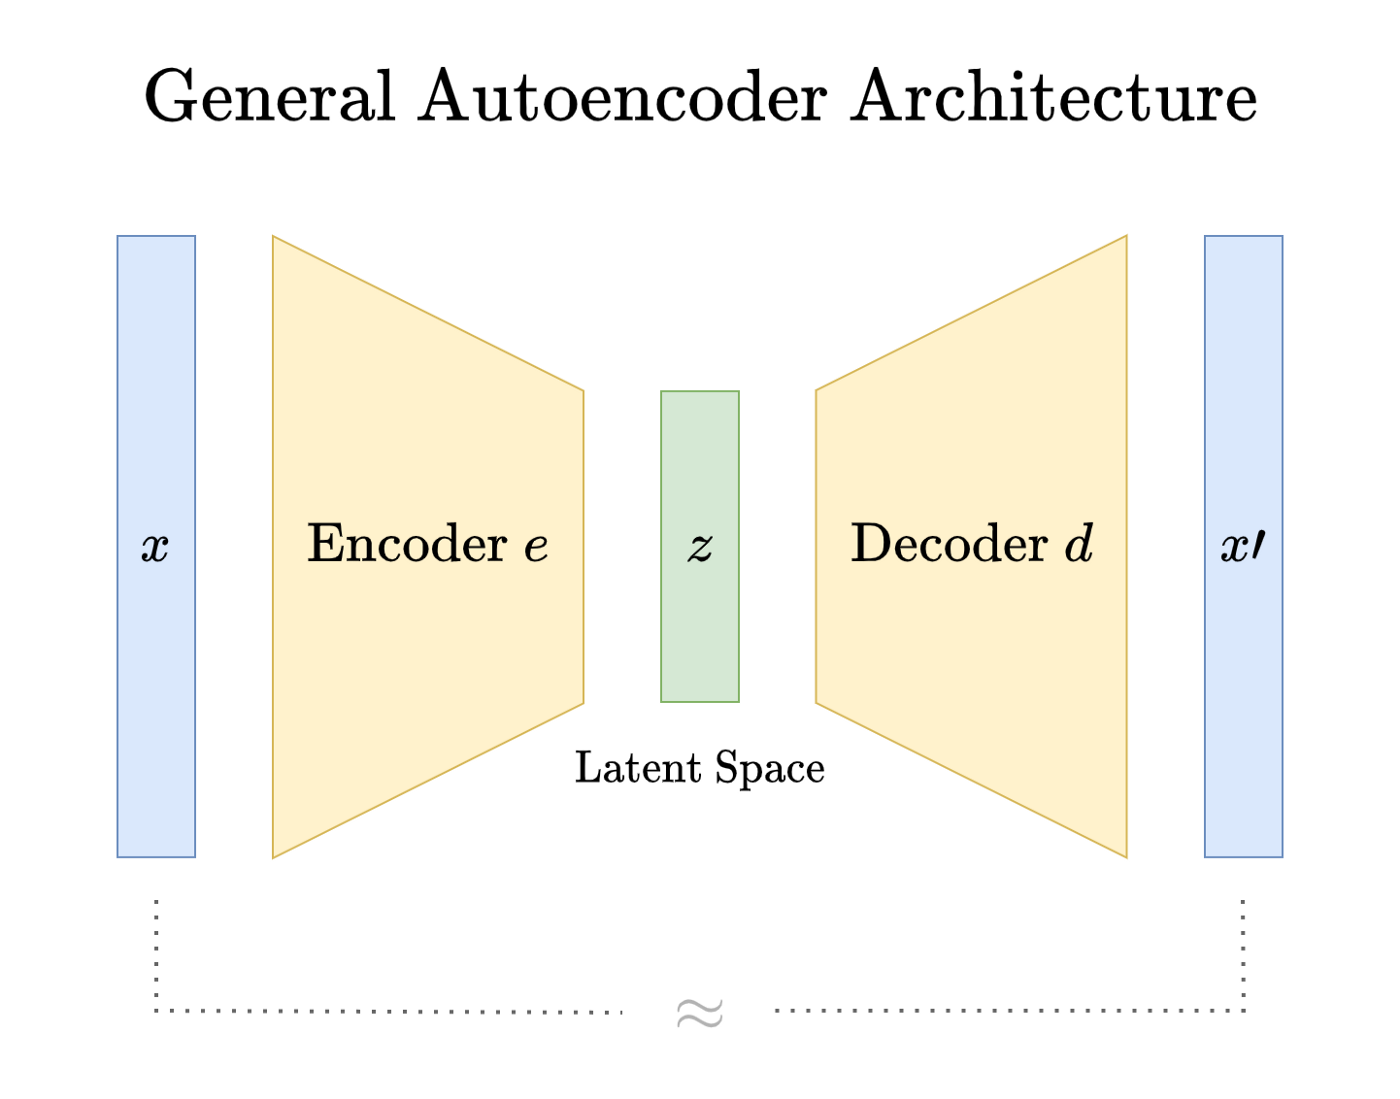

In [ ]:
dim_code = 256 # выберите размер латентного вектора

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=0),   # 45 -> 22
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 22 -> 11
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 11 -> 6
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=0),# 6 -> 2
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Flatten(),  # 256 * 2 * 2 = 1024

            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Unflatten(1, (256, 2, 2)),

            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=0, output_padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Принудительно приводим feature map к исходному размеру без "шахматного" артефакта
            nn.Upsample(size=(45, 45), mode='bilinear', align_corners=False),
            nn.Conv2d(32, 3, kernel_size=3, padding=1), # Сохраняет 45x45
            nn.Sigmoid() # Выход строго в [0, 1] для совместимости с нормализованными данными
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code


In [ ]:
criterion = nn.MSELoss() # <loss>

autoencoder = Autoencoder()

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001) # <Ваш любимый оптимизатор>

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

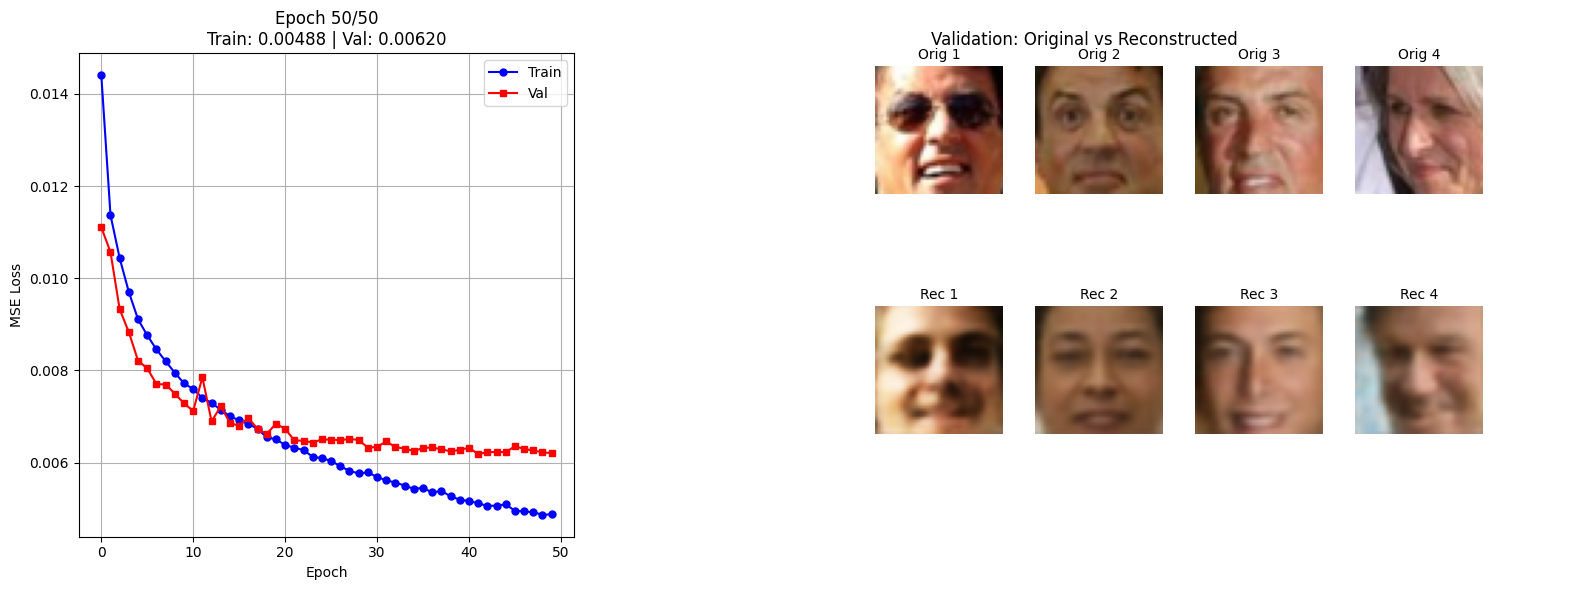

✅ Training finished!


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.to(device)

# Фиксируем 4 изображения из валидации (берем первые, можно изменить индексы)
fixed_val_imgs = val_photos_t[:4].to(device)
fixed_val_imgs_cpu = val_photos_t[:4].cpu()  # для отрисовки на CPU

train_losses, val_losses = [], []

num_epochs = 50

for epoch in range(num_epochs):
    # ==================== TRAIN ====================
    autoencoder.train()
    running_train_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, _ = autoencoder(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * batch.size(0)  # взвешиваем по размеру батча
    train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # ==================== VAL ====================
    autoencoder.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)
            recon, _ = autoencoder(batch)
            loss = criterion(recon, batch)
            running_val_loss += loss.item() * batch.size(0)
    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    # ==================== ВИЗУАЛИЗАЦИЯ ====================
    clear_output(wait=True)  # Очищает вывод ячейки перед новой отрисовкой
    fig = plt.figure(figsize=(16, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])

    # 1. График лоссов (левая часть)
    ax_loss = fig.add_subplot(gs[0])
    ax_loss.plot(train_losses, 'b-o', label='Train', markersize=5)
    ax_loss.plot(val_losses, 'r-s', label='Val', markersize=5)
    ax_loss.set_title(f'Epoch {epoch+1}/{num_epochs}\nTrain: {train_loss:.5f} | Val: {val_loss:.5f}')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('MSE Loss')
    ax_loss.legend()
    ax_loss.grid(True)

    # 2. Сетка реконструкций (правая часть)
    ax_imgs = fig.add_subplot(gs[1])
    ax_imgs.axis('off')
    ax_imgs.set_title('Validation: Original vs Reconstructed')

    with torch.no_grad():
        recon_fixed, _ = autoencoder(fixed_val_imgs)
    recon_fixed_cpu = recon_fixed.cpu()

    # Рисуем 2 ряда по 4 изображения
    for i in range(4):
        orig = np.clip(fixed_val_imgs_cpu[i].permute(1, 2, 0).numpy(), 0, 1)
        rec  = np.clip(recon_fixed_cpu[i].permute(1, 2, 0).numpy(), 0, 1)

        # Оригиналы (верхний ряд)
        ax_orig = fig.add_axes([0.55 + i*0.1, 0.65, 0.08, 0.25])
        ax_orig.imshow(orig)
        ax_orig.set_title(f'Orig {i+1}', fontsize=10, pad=5)
        ax_orig.axis('off')

        # Реконструкции (нижний ряд)
        ax_rec = fig.add_axes([0.55 + i*0.1, 0.25, 0.08, 0.25])
        ax_rec.imshow(rec)
        ax_rec.set_title(f'Rec {i+1}', fontsize=10, pad=5)
        ax_rec.axis('off')

    plt.tight_layout()
    display(fig)
    plt.close(fig)  # Освобождаем память, чтобы не было утечек в долгом обучении

print("✅ Training finished!")

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

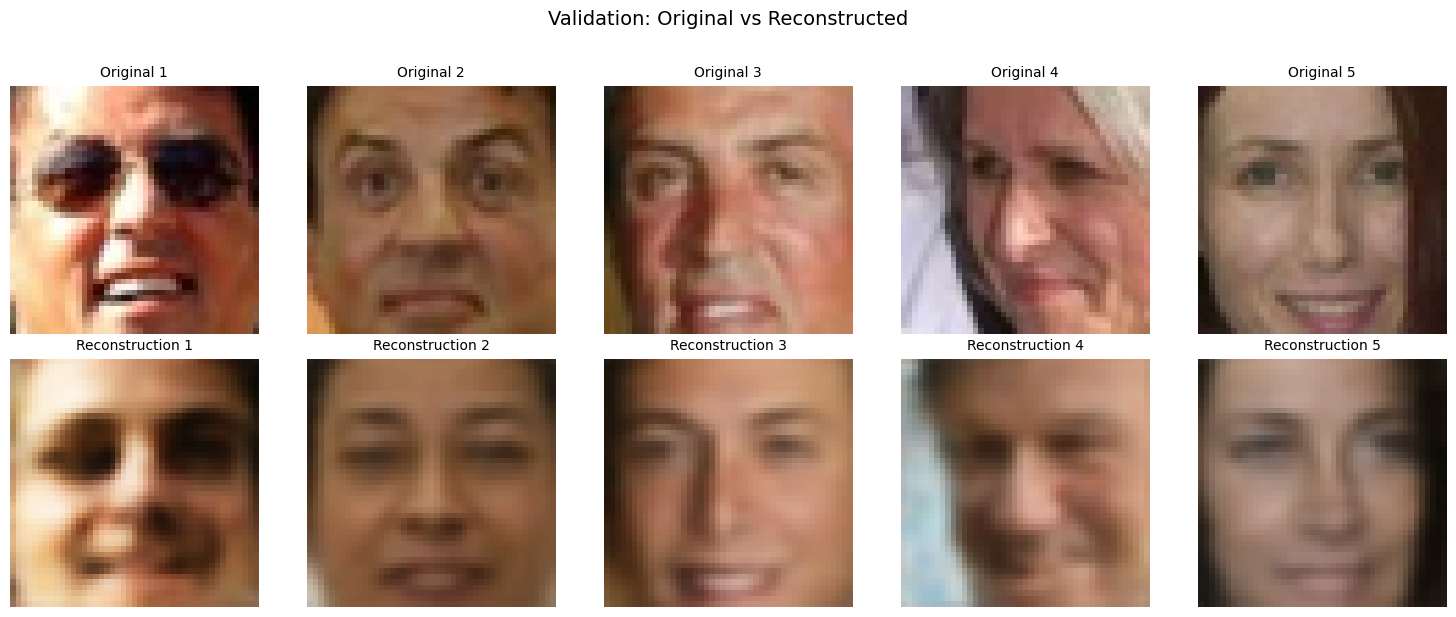

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X = 5  # задайте нужное количество

# 1. Режим оценки + берём первые X изображений
autoencoder.eval()
val_samples = val_photos_t[:X].to(device)

# 2. Инференс без градиентов
with torch.no_grad():
    reconstructions, _ = autoencoder(val_samples)

# 3. Перенос на CPU и конвертация CHW -> HWC
orig_imgs = val_samples.cpu().permute(0, 2, 3, 1).numpy()
recon_imgs = reconstructions.cpu().permute(0, 2, 3, 1).numpy()

# 4. Отрисовка
fig, axes = plt.subplots(2, X, figsize=(X * 3, 6))
axes = np.array(axes).reshape(2, X)  # защита от 1D-массива при X=1

for i in range(X):
    # Оригиналы
    axes[0, i].imshow(np.clip(orig_imgs[i], 0, 1))
    axes[0, i].set_title(f'Original {i+1}', fontsize=10)
    axes[0, i].axis('off')

    # Реконструкции
    axes[1, i].imshow(np.clip(recon_imgs[i], 0, 1))
    axes[1, i].set_title(f'Reconstruction {i+1}', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Validation: Original vs Reconstructed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Что вы можете сказать про результат?

Результат получился достаточно неплохим - реконструированные картинки - это действительно лица. Но они получаются размытыми и непохожими на изначальные картинки с точки зрения самого лица (то есть, если посмотреть на эти лица и задать себе вопрос - это один и тот же человек, или разные, то мы ответим, что разные). В то же время, эмоции изначальных лиц и реконструированных действительно получаются схожими. Для улучшения результата можно изменить лосс на MAE, а также добавить skip connections (U-Net архитектура). Также можно увеличить dim_code до 512.

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

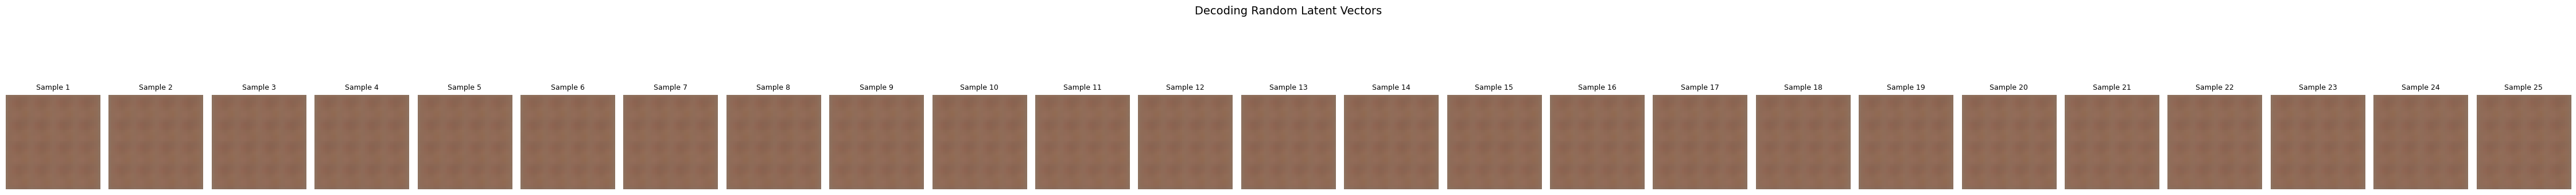

In [ ]:
# сгенерируем 25 рандомных векторов размера latent_space

X = 25

z = torch.randn(X, dim_code, device=device)
with torch.no_grad():
  reconstructions = autoencoder.decoder(z)

# Конвертация CHW -> HWC для matplotlib
recon_imgs = reconstructions.cpu().permute(0, 2, 3, 1).numpy()

# Отрисовка (subplots(1, X) возвращает 1D-массив)
fig, axes = plt.subplots(1, X, figsize=(X * 1.8, 4))
if X == 1:  # защита от краша при X=1
    axes = np.array([axes])

for i in range(X):
    axes[i].imshow(np.clip(recon_imgs[i], 0, 1))
    axes[i].set_title(f'Sample {i+1}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Decoding Random Latent Vectors', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

Мы увидели "усреднённое лицо" (коричневые квадраты) потому что:

1) Обычный AE не учит декодер работать со случайным шумом. Декодер обучался принимать на вход только те векторы, которые выдал его энкодер.
2) Случайные векторы torch.randn попадают в "пустоты" латентного пространства. В этих областях декодер никогда не обучался, поэтому он выдаёт "среднее по датасету" (усреднённый цвет кожи).
3) Нет регуляризации. В отличие от VAE, обычный AE не штрафует латентное пространство за отклонение от нормального распределения.

Вместо чистой генерации попробуем использовать латенты реальных картинок и добавить к ним небольшой шум:

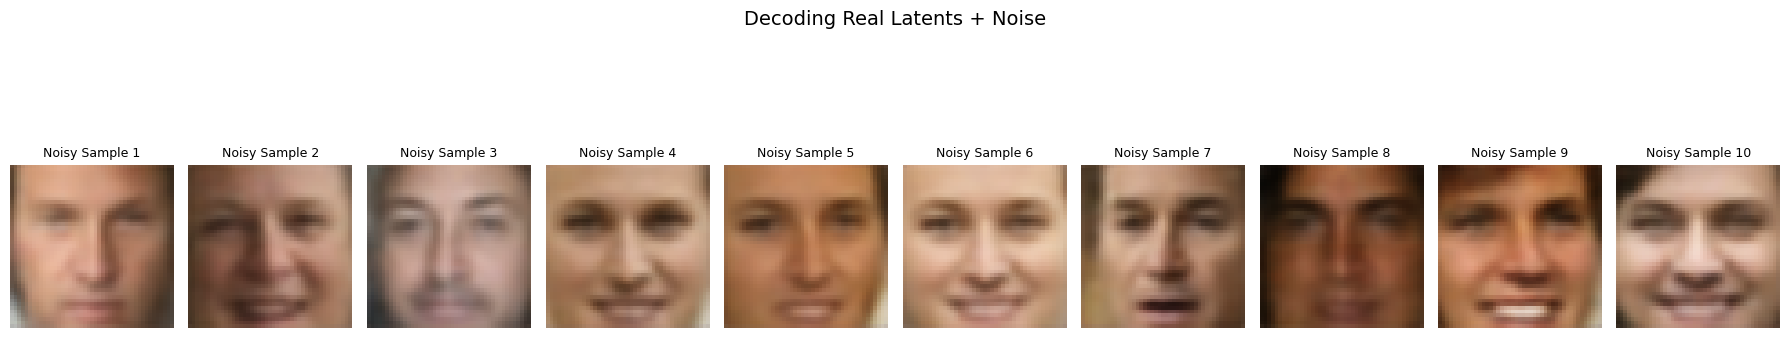

In [ ]:
autoencoder.eval()
X = 10  # количество

# 1. Берём реальные латентные векторы
with torch.no_grad():
    real_latents = autoencoder.encoder(train_photos_t[:X].to(device))

# 2. Добавляем небольшой шум (альтернатива: интерполяция)
noise_level = 0.3  # варианты: 0.1, 0.3, 0.5
z = real_latents + noise_level * torch.randn_like(real_latents)

# 3. Декодируем
with torch.no_grad():
    reconstructions = autoencoder.decoder(z)

# 4. Отрисовка
recon_imgs = reconstructions.cpu().permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(1, X, figsize=(X * 1.8, 4))
if X == 1:
    axes = np.array([axes])

for i in range(X):
    axes[i].imshow(np.clip(recon_imgs[i], 0, 1))
    axes[i].set_title(f'Noisy Sample {i+1}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Decoding Real Latents + Noise', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [ ]:
attrs.head()

,Male,Asian,White,Black,Baby,Child,Youth,Middle Aged,Senior,Black Hair,...,Pale Skin,5 o' Clock Shadow,Strong Nose-Mouth Lines,Wearing Lipstick,Flushed Face,High Cheekbones,Brown Eyes,Wearing Earrings,Wearing Necktie,Wearing Necklace
0,1.568346,-1.889043,1.737203,-0.929729,-1.471799,-0.19558,-0.835609,-0.351468,-1.012533,-0.719593,...,0.361738,1.166118,-1.164916,-1.13999,-2.371746,-1.299932,-0.414682,-1.144902,0.694007,-0.826609
1,0.169851,-0.982408,0.422709,-1.282184,-1.36006,-0.867002,-0.452293,-0.197521,-0.956073,-0.802107,...,-0.832036,-0.39768,0.87416,-0.945431,-0.268649,-0.006244,-0.030406,-0.480128,0.66676,-0.496559
2,0.997749,-1.364195,-0.157377,-0.756447,-1.891825,-0.871526,-0.862893,0.031445,-1.341523,-0.090037,...,1.549743,1.884745,-0.999765,-1.359858,-1.912108,-1.095634,0.915126,-0.572332,0.144262,-0.841231
3,1.122719,-1.997799,1.916144,-2.514214,-2.580071,-1.404239,0.057551,0.000196,-1.273512,-1.431462,...,0.567822,-0.176089,1.108125,-1.600944,-3.264613,0.813418,0.308631,-0.848693,0.475941,-0.447025
4,1.078214,-2.008098,1.676211,-2.278056,-2.651845,-1.348408,0.649089,0.017656,-1.889111,-1.857213,...,-1.461474,-0.955283,0.119113,-1.128176,-3.161048,0.08268,-0.439614,-0.359859,-0.760774,-0.410152


In [ ]:
attrs.columns

Index(['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth',
       'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair',
       'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling',
       'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash',
       'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair',
       'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead',
       'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows',
       'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose',
       'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open',
       'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee',
       'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face',
       'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man',
       'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes',
       'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pa

In [ ]:
attrs[['Smiling', 'Frowning']]

,Smiling,Frowning
0,-0.86499,0.766886
1,0.798544,-0.971679
2,0.172817,0.106412
3,0.563327,-0.664429
4,0.507786,-0.488947
...,...,...
13138,-1.001434,1.151181
13139,-0.64957,0.652186
13140,0.475018,-0.725584
13141,0.741653,-0.769613


In [ ]:
smiling_mask = (attrs['Smiling'].values >= 1)
frowning_mask = (attrs['Frowning'].values >= 1)

In [ ]:
# smiling_indexes = attrs[attrs['Smiling'] >= 1].head(15).index.to_list()
# frowning_indexes = attrs[attrs['Frowning'] >= 1].head(15).index.to_list()

In [ ]:
smiling_images = images[smiling_mask][:15]
frowning_images = images[frowning_mask][:15]

Картинки с улыбками:

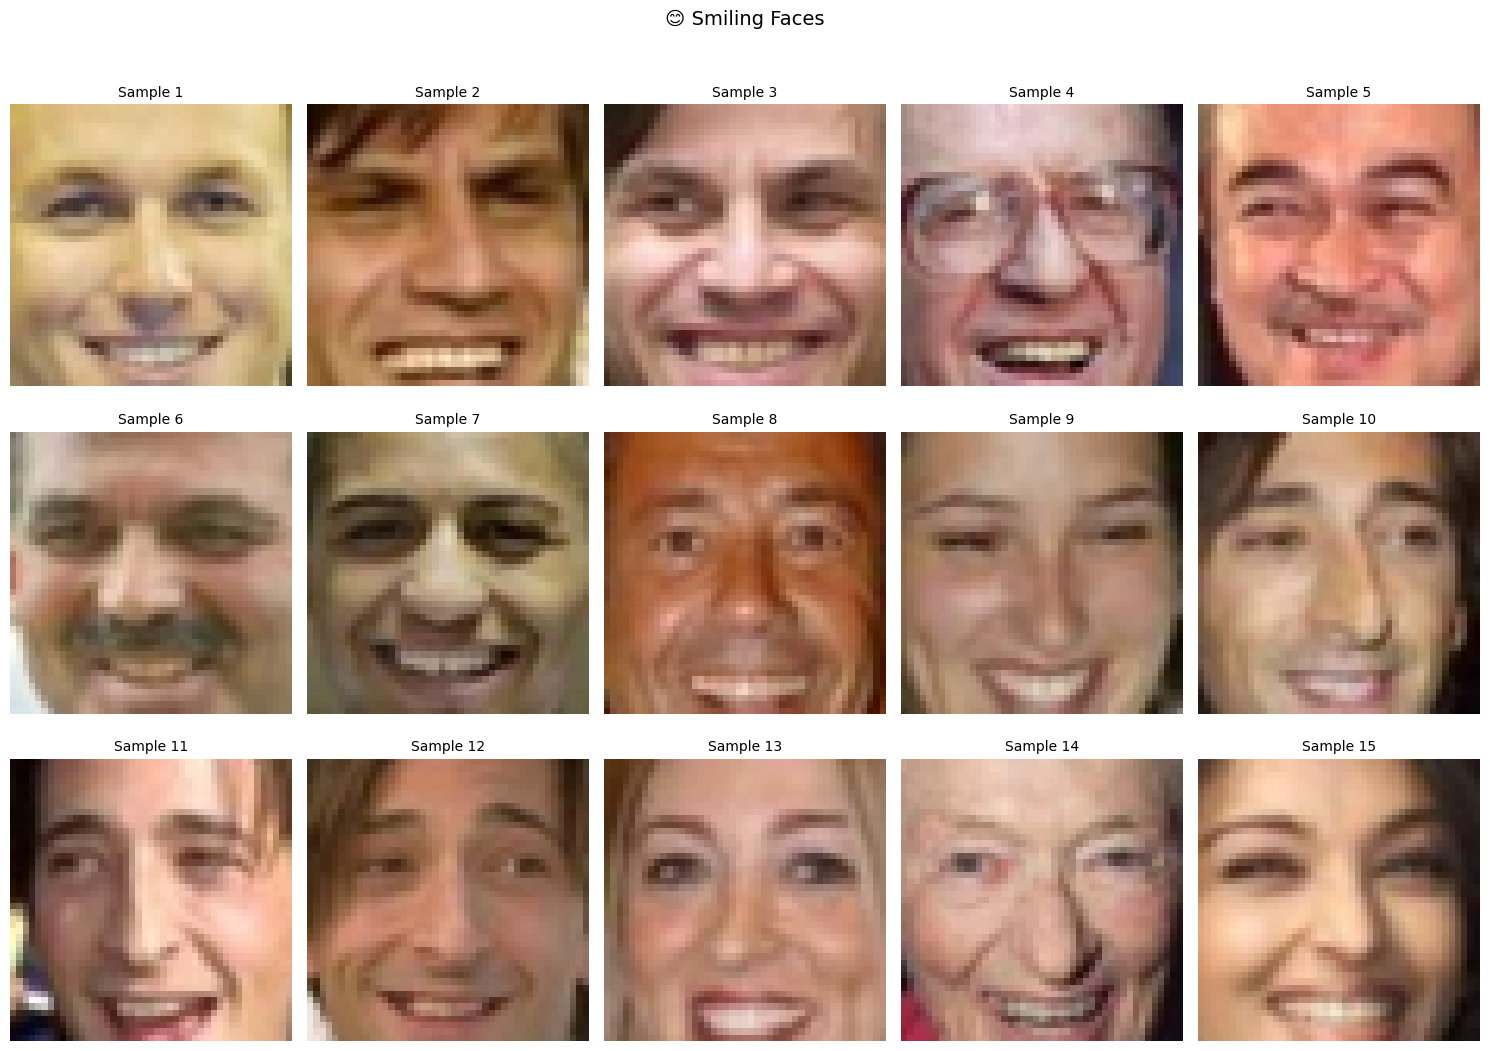

In [ ]:
def plot_faces(imgs, title, n_cols=5):
    n_rows = len(imgs) // n_cols + (1 if len(imgs) % n_cols else 0)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.5))
    axes = np.atleast_1d(axes).flatten()  # защита от 0D/1D массивов при малом N

    for i, ax in enumerate(axes):
        if i < len(imgs):
            ax.imshow(imgs[i])
            ax.set_title(f'Sample {i+1}', fontsize=10)
            ax.axis('off')
        else:
            ax.axis('off')

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# 3. Отрисовка
plot_faces(smiling_images, '😊 Smiling Faces')

Картинки без улыбок:

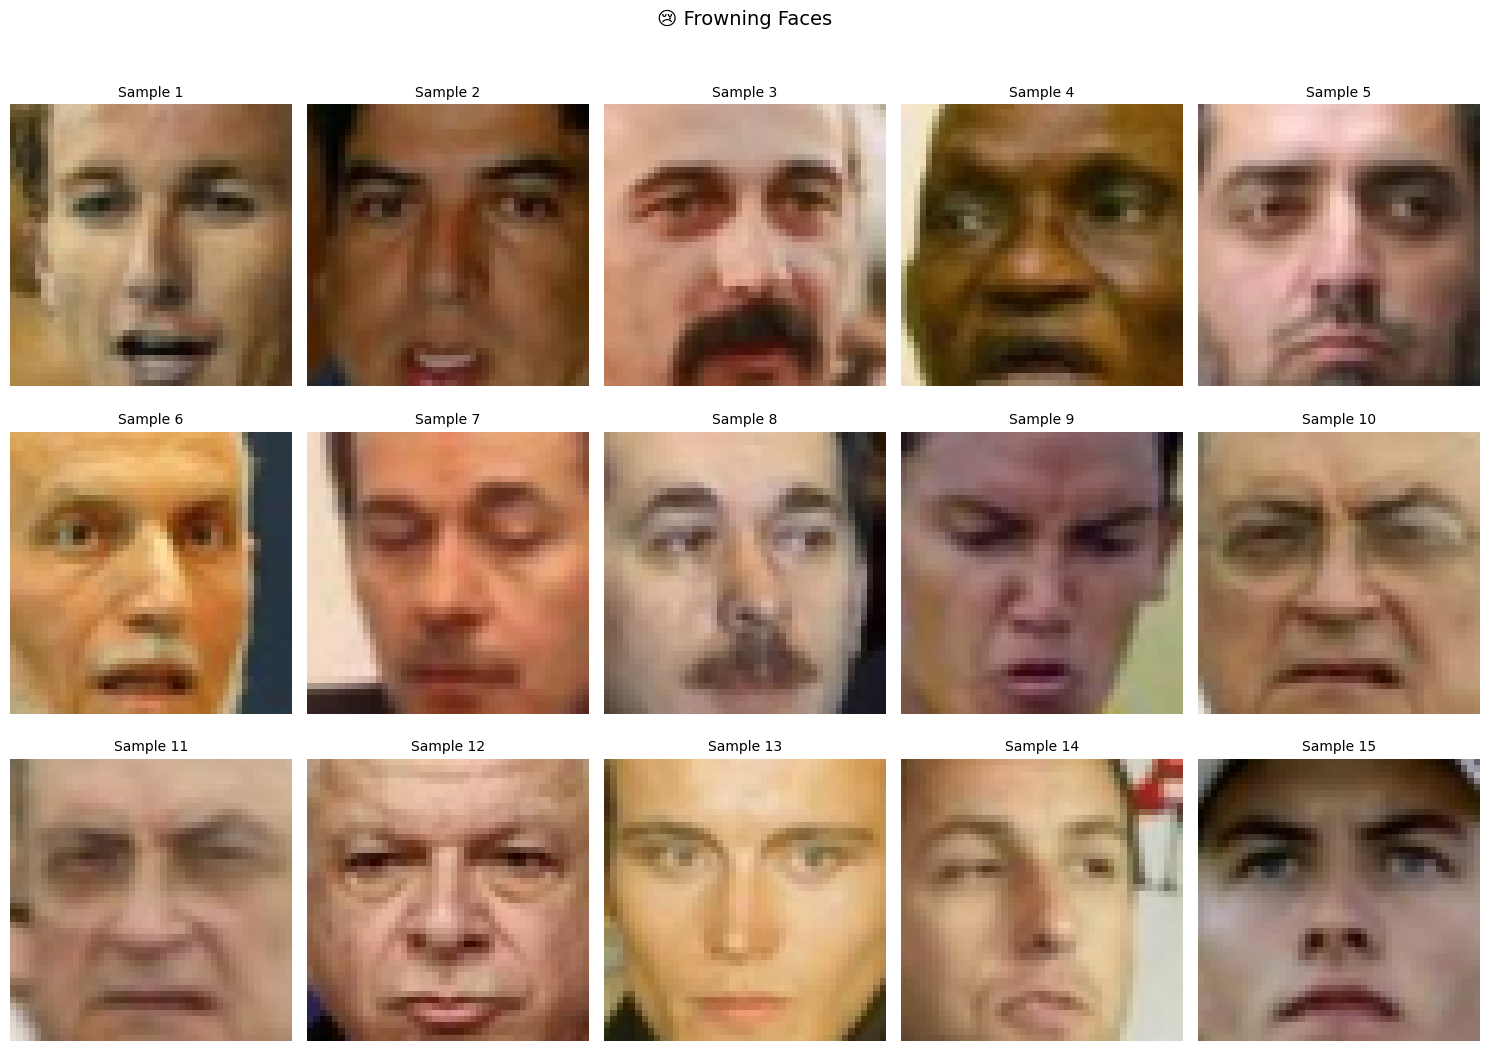

In [ ]:
plot_faces(frowning_images, '😢 Frowning Faces')

Создаём тензоры:

In [ ]:
smiling_t = torch.tensor(smiling_images, dtype=torch.float32) / 255.0
frowning_t = torch.tensor(frowning_images, dtype=torch.float32) / 255.0

In [ ]:
smiling_t = smiling_t.permute(0, 3, 1, 2)  # CHW
frowning_t = frowning_t.permute(0, 3, 1, 2)  # CHW

In [ ]:
# smiling_loader = DataLoader(TensorDataset(smiling_t), batch_size=16, shuffle=True)
# frowning_loader = DataLoader(TensorDataset(frowning_t), batch_size=16, shuffle=True)

Получаем латентные векторы и smile_vector:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.eval()

smiling_t = smiling_t.to(device)
frowning_t = frowning_t.to(device)

with torch.no_grad():
  smiling_latents = autoencoder.encoder(smiling_t)
  frowning_latents = autoencoder.encoder(frowning_t)

# 3. Вычисляем средние векторы и "вектор улыбки"
mean_smiling = smiling_latents.mean(dim=0)   # форма: (256,)
mean_frowning = frowning_latents.mean(dim=0) # форма: (256,)

smile_vector = mean_smiling - mean_frowning  # направление в латентном пространстве

In [ ]:
# Берём одно грустное лицо для демонстрации
idx = 4
target_img = frowning_t[idx:idx+1]  # сохраняем размерность (1, 3, 45, 45)

with torch.no_grad():
    # Кодируем -> добавляем вектор -> декодируем
    target_latent = autoencoder.encoder(target_img)
    modified_latent = target_latent + smile_vector  # можно умножить smile_vector на alpha
    result_img = autoencoder.decoder(modified_latent)

Визуализируем:

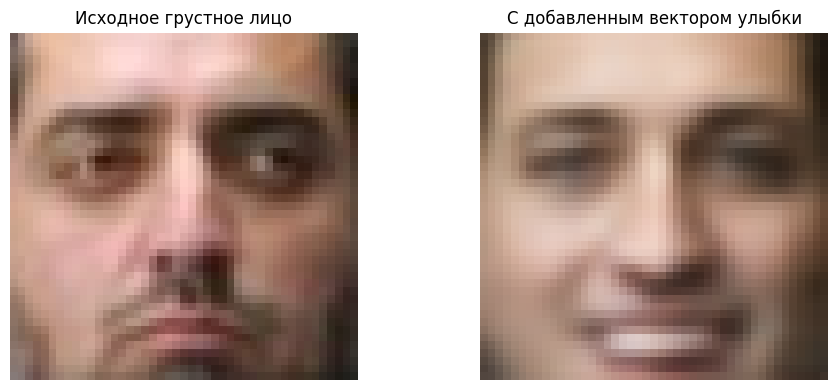

In [ ]:
# Визуализация
orig = target_img.cpu().permute(0, 2, 3, 1).numpy().squeeze()
res  = result_img.cpu().permute(0, 2, 3, 1).numpy().squeeze()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.clip(orig, 0, 1))
axes[0].set_title("Исходное грустное лицо", fontsize=12)
axes[0].axis('off')

axes[1].imshow(np.clip(res, 0, 1))
axes[1].set_title("С добавленным вектором улыбки", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms

In [ ]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        self.latent_dim = latent_dim

        # === ЭНКОДЕР ===
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14 -> 7
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# 7 -> 4
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten() # 128 * 4 * 4 = 2048
        )

        self.fc_mu = nn.Linear(2048, self.latent_dim)
        self.fc_logsigma = nn.Linear(2048, self.latent_dim)

        # === ДЕКОДЕР ===
        self.decoder = nn.Sequential(
            nn.Linear(self.latent_dim, 2048),
            nn.ReLU(),
            nn.Unflatten(1, (128, 4, 4)),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Upsample(size=(28, 28), mode='bilinear', align_corners=False),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            sigma = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(sigma)
            return mu + sigma * eps
        else:
            return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [ ]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - torch.exp(logsigma)) # <напишите код для KL-дивергенции, пользуясь формулой выше>
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = F.binary_cross_entropy(reconstruction, x, reduction='sum') # <binary cross-entropy>
    return loss

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction) # <соедините тут две компоненты лосса. Mind the sign!>

И обучим модель:

In [ ]:
criterion = loss_vae

autoencoder = VAE()

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001) # <Ваш любимый оптимизатор>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
autoencoder.to(device)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): AdaptiveAvgPool2d(output_size=(4, 4))
    (7): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=2048, out_features=32, bias=True)
  (fc_logsigma): Linear(in_features=2048, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=2048, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(128, 4, 4))
    (3): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2

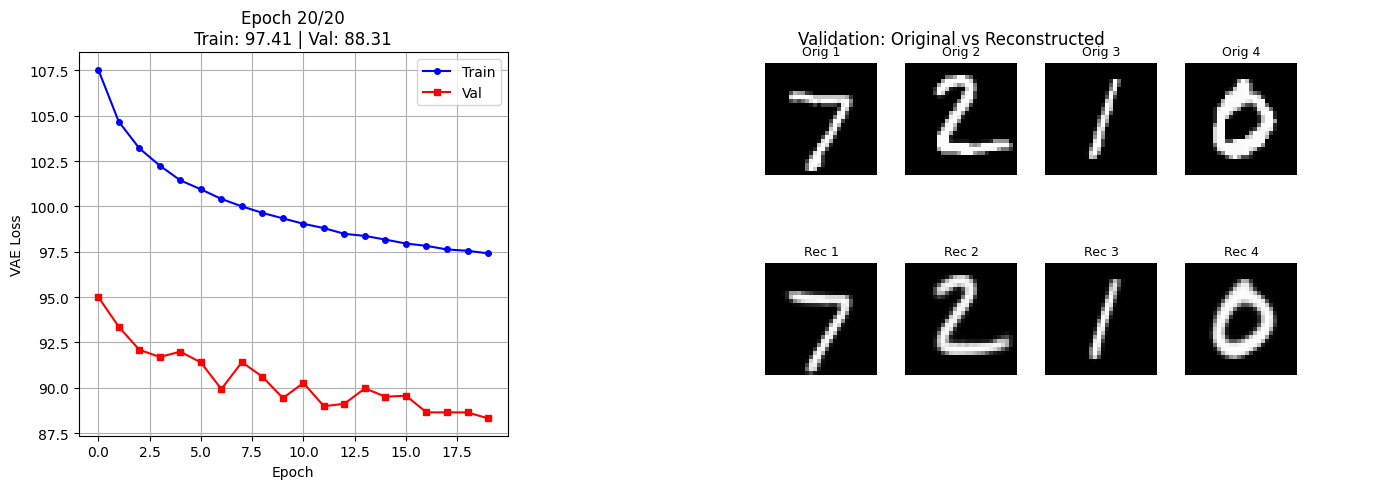

✅ Training finished!


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

# Фиксируем 4 картинки из тестовой выборки для визуализации
# next(iter(test_loader)) берет первый батч
fixed_val_imgs, _ = next(iter(test_loader))
fixed_val_imgs = fixed_val_imgs[:4].to(device)
fixed_val_imgs_cpu = fixed_val_imgs[:4].cpu()

train_losses, val_losses = [], []
num_epochs = 20 # Для MNIST обычно хватает 10-20 эпох

for epoch in range(num_epochs):
    # ==================== TRAIN ====================
    autoencoder.train()
    running_train_loss = 0.0

    # MNIST DataLoader возвращает кортеж (images, labels), нам нужны только images
    for batch, _ in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # VAE возвращает 3 значения: mu, logsigma, reconstruction
        mu, logsigma, reconstruction = autoencoder(batch)

        # Передаем аргументы в том порядке, как в функции loss_vae(x, mu, logsigma, reconstruction)
        loss = criterion(batch, mu, logsigma, reconstruction)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # ==================== VAL ====================
    autoencoder.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch, _ in test_loader:
            batch = batch.to(device)
            mu, logsigma, reconstruction = autoencoder(batch)
            loss = criterion(batch, mu, logsigma, reconstruction)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(test_loader.dataset)
    val_losses.append(val_loss)

    # ==================== ВИЗУАЛИЗАЦИЯ ====================
    clear_output(wait=True)
    fig = plt.figure(figsize=(14, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])

    # 1. График лоссов
    ax_loss = fig.add_subplot(gs[0])
    ax_loss.plot(train_losses, 'b-o', label='Train', markersize=4)
    ax_loss.plot(val_losses, 'r-s', label='Val', markersize=4)
    ax_loss.set_title(f'Epoch {epoch+1}/{num_epochs}\nTrain: {train_loss:.2f} | Val: {val_loss:.2f}')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('VAE Loss')
    ax_loss.legend()
    ax_loss.grid(True)

    # 2. Сетка реконструкций
    ax_imgs = fig.add_subplot(gs[1])
    ax_imgs.axis('off')
    ax_imgs.set_title('Validation: Original vs Reconstructed')

    with torch.no_grad():
        # На инференсе VAE возвращает mu (детерминированно), но нам нужна реконструкция (3-й элемент)
        _, _, recon_fixed = autoencoder(fixed_val_imgs)
    recon_fixed_cpu = recon_fixed.cpu()

    for i in range(4):
        # Для MNIST (1 канал) используем squeeze() и cmap='gray'
        orig = fixed_val_imgs_cpu[i].squeeze().numpy()
        rec  = recon_fixed_cpu[i].squeeze().numpy()

        ax_orig = fig.add_axes([0.55 + i*0.1, 0.6, 0.08, 0.3])
        ax_orig.imshow(orig, cmap='gray')
        ax_orig.set_title(f'Orig {i+1}', fontsize=9)
        ax_orig.axis('off')

        ax_rec = fig.add_axes([0.55 + i*0.1, 0.2, 0.08, 0.3])
        ax_rec.imshow(rec, cmap='gray')
        ax_rec.set_title(f'Rec {i+1}', fontsize=9)
        ax_rec.axis('off')

    plt.tight_layout()
    display(fig)
    plt.close(fig)

print("✅ Training finished!")

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

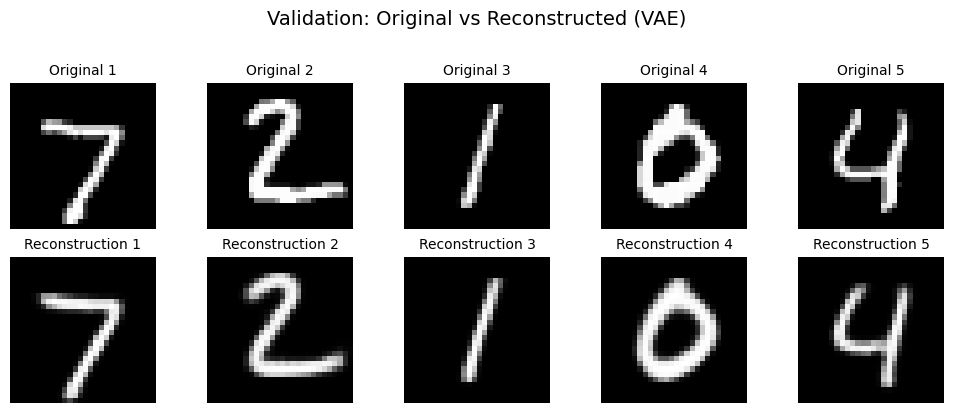

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X = 5  # задайте нужное количество

# 1. Режим оценки + берём первые X изображений из ТЕСТОВОЙ выборки
autoencoder.eval()

# Получаем данные из DataLoader (MNIST отдает кортеж (img, label))
val_data, _ = next(iter(test_loader))
val_samples = val_data[:X].to(device)

# 2. Инференс без градиентов
with torch.no_grad():
    # ВАЖНО: VAE возвращает (mu, logsigma, reconstruction)
    # Нам нужен только 3-й элемент — реконструкция
    _, _, reconstructions = autoencoder(val_samples)

# 3. Перенос на CPU и подготовка для matplotlib
# Для MNIST (1 канал) используем squeeze(1), чтобы убрать лишнюю размерность.
# В старом коде был permute(0, 2, 3, 1), но он нужен для RGB (3 каналов).
orig_imgs = val_samples.cpu().squeeze(1).numpy()
recon_imgs = reconstructions.cpu().squeeze(1).numpy()

# 4. Отрисовка
fig, axes = plt.subplots(2, X, figsize=(X * 2, 4)) # Размер поменьше, т.к. цифры маленькие
axes = np.array(axes).reshape(2, X)  # защита от 1D-массива при X=1

for i in range(X):
    # Оригиналы
    axes[0, i].imshow(orig_imgs[i], cmap='gray')  # <-- добавлен cmap='gray'
    axes[0, i].set_title(f'Original {i+1}', fontsize=10)
    axes[0, i].axis('off')

    # Реконструкции
    axes[1, i].imshow(recon_imgs[i], cmap='gray') # <-- добавлен cmap='gray'
    axes[1, i].set_title(f'Reconstruction {i+1}', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Validation: Original vs Reconstructed (VAE)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

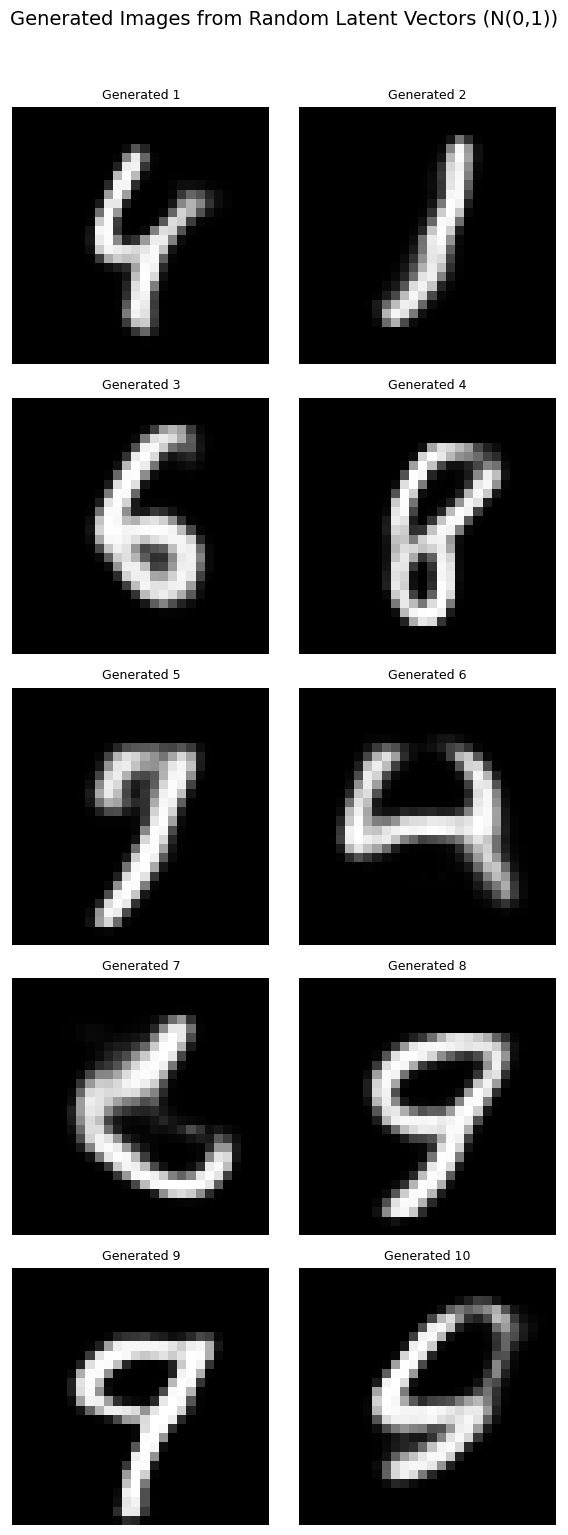

In [ ]:
autoencoder.eval()  # Режим инференса

X = 10  # количество генерируемых изображений
latent_dim = 32  # Должно совпадать с latent_dim в классе VAE

# 1. Генерация случайного шума из нормального распределения
# Форма: (X, latent_dim), сразу на нужном устройстве
z = torch.randn(X, latent_dim, device=device)

# 2. Прогон через декодер (без градиентов)
with torch.no_grad():  # Экономит память и ускоряет работу
    output = autoencoder.decoder(z)

# 3. Подготовка к отрисовке
# output имеет форму (10, 1, 28, 28).
# squeeze(1) убирает канал, чтобы получить (10, 28, 28) для imshow
output_imgs = output.cpu().squeeze(1).numpy()

# 4. Отрисовка сетки
# Создаём сетку: если 10 картинок, то 5 строк × 2 колонки
fig, axes = plt.subplots(X // 2, 2, figsize=(6, 15))
axes = np.array(axes).flatten()  # Превращаем в 1D массив для удобной индексации

for i in range(X):
    axes[i].imshow(output_imgs[i], cmap='gray')  # cmap='gray' для ч/б MNIST
    axes[i].set_title(f'Generated {i+1}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Generated Images from Random Latent Vectors (N(0,1))', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

✅ Собрали 2000 латентных векторов формы (2000, 32)
🔄 Запускаем t-SNE (это может занять 1-5 минут)...
✅ t-SNE завершён!


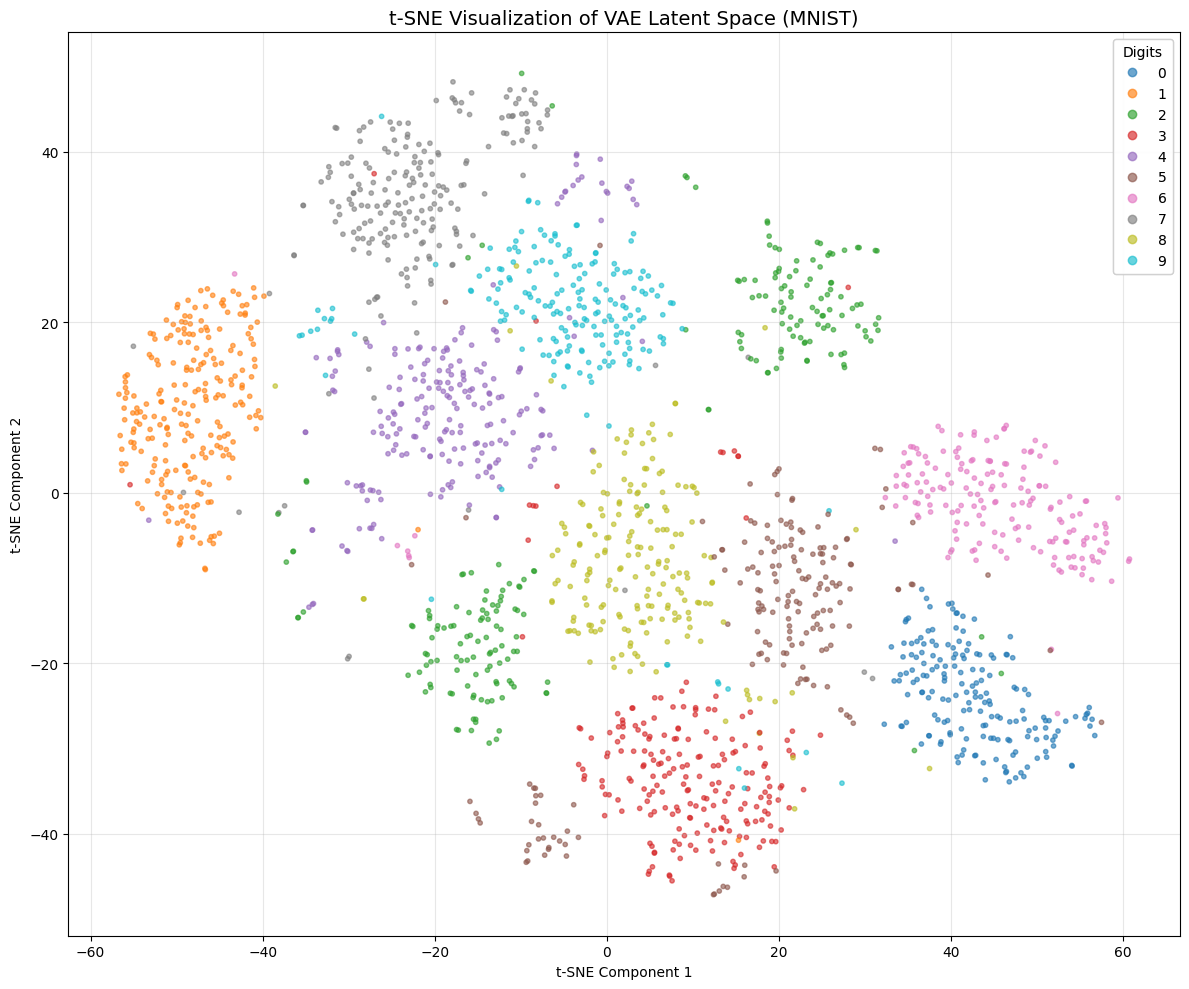

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

autoencoder.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Собираем латентные векторы и метки из тестового датасета
# Берём подвыборку: t-SNE очень медленный на больших данных (10к+ точек)
n_samples = 2000  # можно увеличить

latents_list = []
labels_list = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        if len(latents_list) * test_loader.batch_size >= n_samples:
            break

        images = images.to(device)
        labels = labels.numpy()

        # Кодируем: VAE возвращает (mu, logsigma)
        mu, _ = autoencoder.encode(images)

        # Переносим на CPU и добавляем в список
        latents_list.append(mu.cpu().numpy())
        labels_list.append(labels)

# Конкатенируем всё в большие массивы
latents = np.concatenate(latents_list, axis=0)[:n_samples]
labels = np.concatenate(labels_list, axis=0)[:n_samples]

print(f"✅ Собрали {len(latents)} латентных векторов формы {latents.shape}")

# 2. Применяем t-SNE для сжатия до 2D
print("🔄 Запускаем t-SNE (это может занять 1-5 минут)...")
tsne = TSNE(
    n_components=2,
    perplexity=30,      # типичное значение 5-50, влияет на локальность
    learning_rate='auto', # авто-подбор шага обучения (sklearn >= 1.0)
    init='pca',         # инициализация через PCA для стабильности
    random_state=42,
    n_jobs=-1           # использовать все ядра CPU
)

latents_2d = tsne.fit_transform(latents)
print("✅ t-SNE завершён!")

# 3. Визуализация
plt.figure(figsize=(12, 10))

# scatter с цветовым кодированием по меткам (0-9)
scatter = plt.scatter(
    latents_2d[:, 0],
    latents_2d[:, 1],
    c=labels,              # раскраска по классам
    cmap='tab10',          # 10 различных цветов для цифр 0-9
    s=10,                  # размер точки
    alpha=0.6              # прозрачность для лучшей видимости скоплений
)

# Добавляем легенду с цифрами
legend1 = plt.legend(*scatter.legend_elements(), title="Digits", loc="best")
plt.gca().add_artist(legend1)

plt.title('t-SNE Visualization of VAE Latent Space (MNIST)', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Что вы думаете о виде латентного представления?

**Ответ:** Точки одного цвета (одинаковой цифры) собираются в плотные, хорошо отделяемые облака. Это означает, что энкодер успешно научился выделять признаки, которые однозначно идентифицируют цифру. Семантически одинаковые объекты лежат рядом в латентном пространстве. Кластеры цифр, которые пишутся похоже, расположены ближе друг к другу.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CVAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = 10

        # === ЭНКОДЕР ===
        # Вход: Изображение (1 канал) + Класс (10 каналов, повторенных на всю картинку)
        # Итого: 1 + 10 = 11 входных каналов
        self.encoder = nn.Sequential(
            nn.Conv2d(11, 32, kernel_size=3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),   # 14 -> 7
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 7 -> 4
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten() # 128 * 4 * 4 = 2048
        )

        # Головы энкодера (размер не меняется, так как латентный вектор всегда одной длины)
        self.fc_mu = nn.Linear(2048, latent_dim)
        self.fc_logsigma = nn.Linear(2048, latent_dim)

        # === ДЕКОДЕР ===
        # Вход: Латентный вектор (32) + Класс (10) = 42 нейрона на входе
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + 10, 2048), # <-- Размер входа увеличен на 10!
            nn.ReLU(),
            nn.Unflatten(1, (128, 4, 4)),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Upsample(size=(28, 28), mode='bilinear', align_corners=False),
            nn.Sigmoid()
        )

    def encode(self, x, class_num):
        # 1. Превращаем класс (число 0-9) в One-Hot вектор (0,0,0,1...)
        # shape: (Batch, 10)
        label = F.one_hot(class_num, num_classes=self.num_classes).float()

        # 2. Подготовка лейбла для конкатенации с картинкой (2D)
        # Нам нужно превратить (B, 10) в (B, 10, 28, 28)
        label = label.view(label.size(0), self.num_classes, 1, 1)
        label = label.expand(-1, -1, 28, 28)

        # 3. Конкатенация: [Batch, 1, 28, 28] + [Batch, 10, 28, 28] -> [Batch, 11, 28, 28]
        x_c = torch.cat([x, label], dim=1)

        # 4. Пропускаем через энкодер
        h = self.encoder(x_c)

        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)

        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            sigma = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(sigma)
            return mu + sigma * eps
        else:
            return mu

    def decode(self, z, class_num):
        # 1. Превращаем класс в One-Hot вектор
        label = F.one_hot(class_num, num_classes=self.num_classes).float()

        # 2. Конкатенация латентного вектора и класса (склейка по последнему измерению)
        # z: [Batch, 32], label: [Batch, 10] -> [Batch, 42]
        z_c = torch.cat([z, label], dim=1)

        # 3. Пропускаем через декодер
        reconstruction = self.decoder(z_c)

        return reconstruction

    def forward(self, x, class_num):
        # Полный проход: x (картинка) и class_num (метка)
        mu, logsigma, class_num_out = self.encode(x, class_num)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, class_num_out)
        return mu, logsigma, reconstruction

Обучение:

In [ ]:
criterion = loss_vae

model = CVAE()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # <Ваш любимый оптимизатор>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model.to(device)

CVAE(
  (encoder): Sequential(
    (0): Conv2d(11, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): AdaptiveAvgPool2d(output_size=(4, 4))
    (7): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=2048, out_features=32, bias=True)
  (fc_logsigma): Linear(in_features=2048, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=42, out_features=2048, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(128, 4, 4))
    (3): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2,

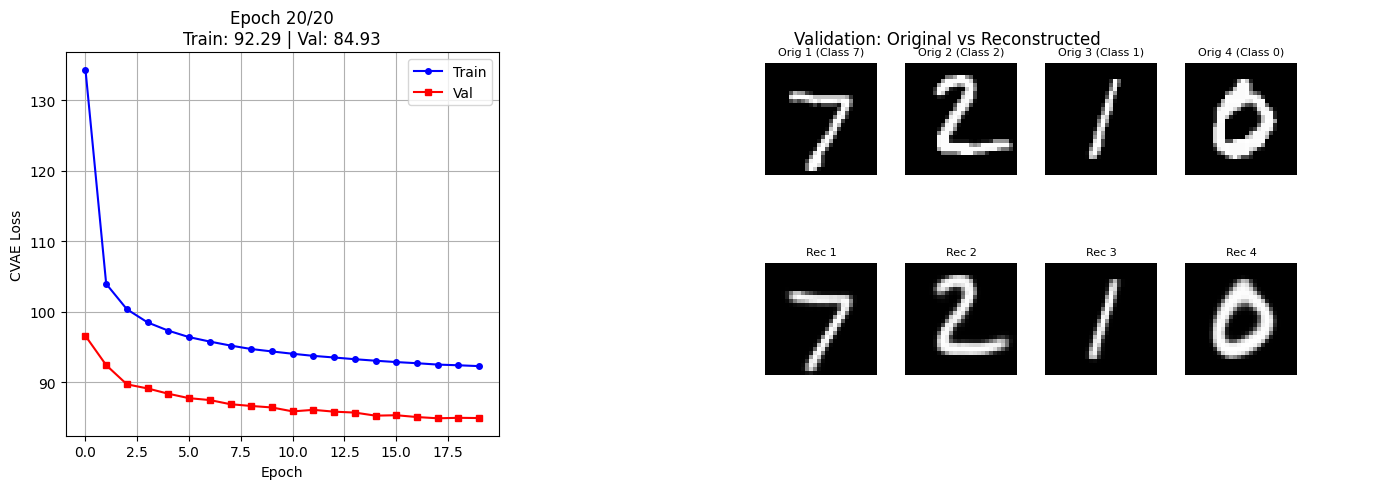

✅ CVAE Training finished!


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

fixed_val_imgs, fixed_val_labels = next(iter(test_loader))
fixed_val_imgs = fixed_val_imgs[:4].to(device)
fixed_val_labels = fixed_val_labels[:4].to(device)  # Сохраняем метки!
fixed_val_imgs_cpu = fixed_val_imgs[:4].cpu()

train_losses, val_losses = [], []
num_epochs = 20

for epoch in range(num_epochs):
    # ==================== TRAIN ====================
    model.train()
    running_train_loss = 0.0

    # CVAE: DataLoader возвращает (images, labels) - используем оба
    for batch_images, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)  # Передаём метки

        optimizer.zero_grad()

        # CVAE forward: передаём и картинки, и метки
        mu, logsigma, reconstruction = model(batch_images, batch_labels)

        loss = criterion(batch_images, mu, logsigma, reconstruction)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # ==================== VAL ====================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch_images, batch_labels in test_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            # CVAE: передаём метки
            mu, logsigma, reconstruction = model(batch_images, batch_labels)
            loss = criterion(batch_images, mu, logsigma, reconstruction)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(test_loader.dataset)
    val_losses.append(val_loss)

    # ==================== ВИЗУАЛИЗАЦИЯ ====================
    clear_output(wait=True)
    fig = plt.figure(figsize=(14, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])

    # 1. График лоссов
    ax_loss = fig.add_subplot(gs[0])
    ax_loss.plot(train_losses, 'b-o', label='Train', markersize=4)
    ax_loss.plot(val_losses, 'r-s', label='Val', markersize=4)
    ax_loss.set_title(f'Epoch {epoch+1}/{num_epochs}\nTrain: {train_loss:.2f} | Val: {val_loss:.2f}')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('CVAE Loss')
    ax_loss.legend()
    ax_loss.grid(True)

    # 2. Сетка реконструкций
    ax_imgs = fig.add_subplot(gs[1])
    ax_imgs.axis('off')
    ax_imgs.set_title('Validation: Original vs Reconstructed')

    with torch.no_grad():
        # CVAE: передаём и фиксированные картинки, и их метки
        _, _, recon_fixed = model(fixed_val_imgs, fixed_val_labels)
    recon_fixed_cpu = recon_fixed.cpu()

    for i in range(4):
        # Для MNIST (1 канал) используем squeeze() и cmap='gray'
        orig = fixed_val_imgs_cpu[i].squeeze().numpy()
        rec  = recon_fixed_cpu[i].squeeze().numpy()

        ax_orig = fig.add_axes([0.55 + i*0.1, 0.6, 0.08, 0.3])
        ax_orig.imshow(orig, cmap='gray')
        ax_orig.set_title(f'Orig {i+1} (Class {fixed_val_labels[i].item()})', fontsize=8)
        ax_orig.axis('off')

        ax_rec = fig.add_axes([0.55 + i*0.1, 0.2, 0.08, 0.3])
        ax_rec.imshow(rec, cmap='gray')
        ax_rec.set_title(f'Rec {i+1}', fontsize=8)
        ax_rec.axis('off')

    plt.tight_layout()
    display(fig)
    plt.close(fig)

print("✅ CVAE Training finished!")

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

Генерация класса 5:

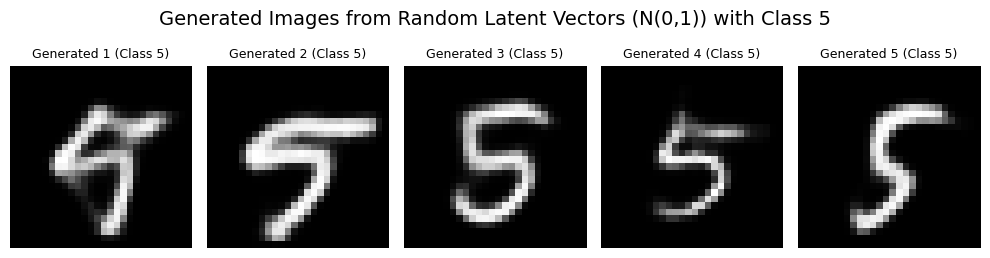

In [ ]:
# Генерируем 5 семерок (class = 7)
target_class = torch.tensor([5] * 5).to(device)
noise = torch.randn(5, 32).to(device)          # Случайный шум

model.eval()
with torch.no_grad():
    # Передаем шум и желаемый класс в декодер
    generated_images = model.decode(noise, target_class)

# Подготовка к отрисовке
# squeeze(1) убирает канал, чтобы получить (10, 28, 28) для imshow
output_imgs = generated_images.cpu().squeeze(1).numpy()

# Отрисовка сетки
n_images = len(target_class)
n_cols = 5  # Фиксируем 5 колонок
n_rows = (n_images + n_cols - 1) // n_cols  # Округление вверх

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.5))
axes = np.array(axes).flatten()  # Превращаем в 1D массив

for i in range(n_images):
    axes[i].imshow(output_imgs[i], cmap='gray')
    axes[i].set_title(f'Generated {i+1} (Class 5)', fontsize=9)
    axes[i].axis('off')

# Скрываем лишние ячейки, если они есть
for i in range(n_images, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Generated Images from Random Latent Vectors (N(0,1)) with Class 5',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Генерация класса 7:

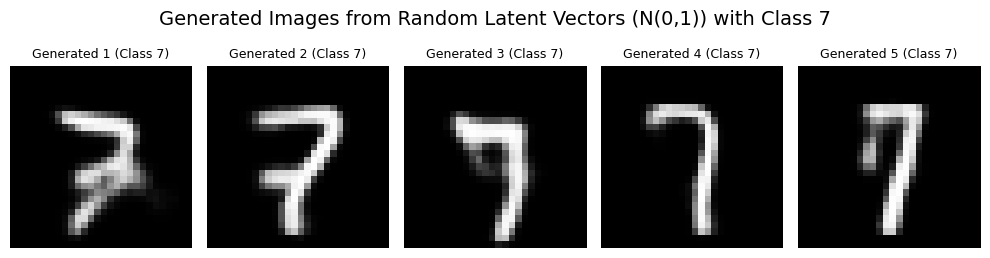

In [ ]:
# Генерируем 5 семерок (class = 7)
target_class = torch.tensor([7] * 5).to(device) # Вектор из семерок: [7, 7, 7, 7, 7]
noise = torch.randn(5, 32).to(device)          # Случайный шум

model.eval()
with torch.no_grad():
    # Передаем шум и желаемый класс в декодер
    generated_images = model.decode(noise, target_class)

# Подготовка к отрисовке
# squeeze(1) убирает канал, чтобы получить (10, 28, 28) для imshow
output_imgs = generated_images.cpu().squeeze(1).numpy()

# Отрисовка сетки
n_images = len(target_class)
n_cols = 5  # Фиксируем 5 колонок
n_rows = (n_images + n_cols - 1) // n_cols  # Округление вверх

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.5))
axes = np.array(axes).flatten()  # Превращаем в 1D массив

for i in range(n_images):
    axes[i].imshow(output_imgs[i], cmap='gray')
    axes[i].set_title(f'Generated {i+1} (Class 7)', fontsize=9)
    axes[i].axis('off')

# Скрываем лишние ячейки, если они есть
for i in range(n_images, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Generated Images from Random Latent Vectors (N(0,1)) with Class 7',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

✅ Собрали 2000 латентных векторов формы (2000, 32)
🔄 Запускаем t-SNE...
✅ t-SNE завершён!


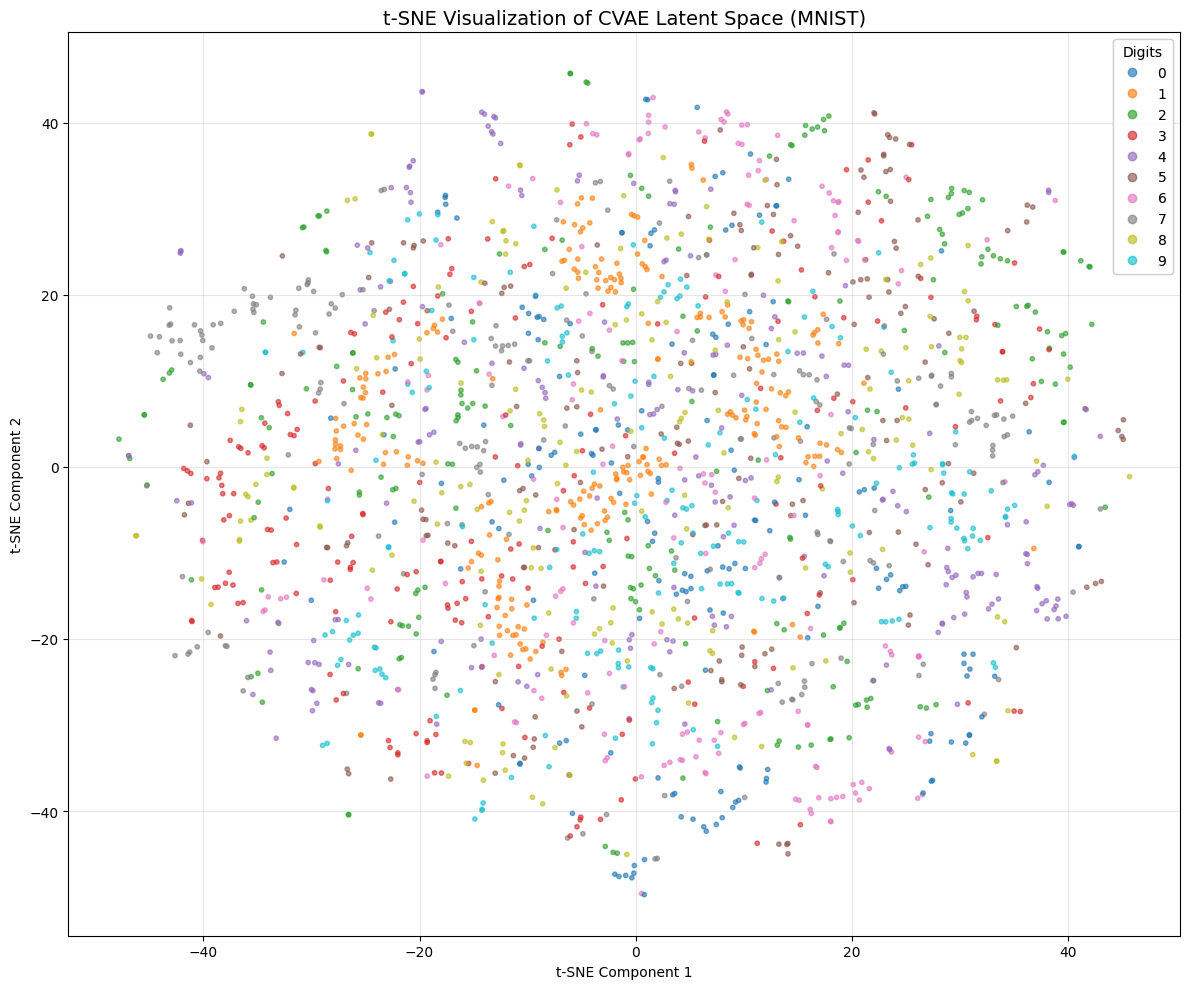

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_samples = 2000  # подвыборка для скорости t-SNE
latents_list = []
labels_list = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        if len(latents_list) * test_loader.batch_size >= n_samples:
            break

        images = images.to(device)
        labels = labels.to(device)  # Метки нужны энкодеру CVAE

        # Передаём labels в encode
        mu, _, _ = model.encode(images, labels)

        latents_list.append(mu.cpu().numpy())
        labels_list.append(labels.cpu().numpy())

# Собираем массивы
latents = np.concatenate(latents_list, axis=0)[:n_samples]
labels = np.concatenate(labels_list, axis=0)[:n_samples]

print(f"✅ Собрали {len(latents)} латентных векторов формы {latents.shape}")

# 2. t-SNE (без изменений)
print("🔄 Запускаем t-SNE...")
tsne = TSNE(
    n_components=2, perplexity=30, learning_rate='auto',
    init='pca', random_state=42, n_jobs=-1
)
latents_2d = tsne.fit_transform(latents)
print("✅ t-SNE завершён!")

# 3. Визуализация (без изменений)
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    latents_2d[:, 0], latents_2d[:, 1],
    c=labels, cmap='tab10', s=10, alpha=0.6
)
legend1 = plt.legend(*scatter.legend_elements(), title="Digits", loc="best")
plt.gca().add_artist(legend1)

plt.title('t-SNE Visualization of CVAE Latent Space (MNIST)', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

**Ответ:** Все классы "размазаны" по пространству стилей. Нет кластеров по классам, как в случае с VAE. Это происходит потому, что энкодер получает класс как вход (x + label). Поэтому ему не нужно кодировать класс в z. В CVAE z кодирует только стиль (наклон, толщину линий, вариации внутри класса). Т.е. класс цифры кодируется через условие (label), а латентный вектор z отвечает только за стиль написания (вариации внутри класса). Такое разделение позволяет CVAE генерировать цифры заданного класса по требованию.

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [21]:
# noise_factor = 0.5
# X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

Подготовка датасета:

In [22]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [23]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [24]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [25]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [26]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images_clean, attrs = fetch_dataset()

In [37]:
noise_factor = 50.0
images_noisy = images_clean + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images_clean.shape)
images_noisy = np.clip(images_noisy, 0, 255).astype('uint8') # обрезать шум, чтобы не выйти за границы

In [38]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(images_clean))
train_idx, val_idx = train_test_split(indices, train_size=0.9, shuffle=False)

train_photos_noisy = images_noisy[train_idx]
train_photos_clean = images_clean[train_idx]

val_photos_noisy = images_noisy[val_idx]
val_photos_clean = images_clean[val_idx]


In [39]:
# Нормализация
train_noisy_t = torch.tensor(train_photos_noisy, dtype=torch.float32) / 255.0
train_clean_t = torch.tensor(train_photos_clean, dtype=torch.float32) / 255.0

val_noisy_t = torch.tensor(val_photos_noisy, dtype=torch.float32) / 255.0
val_clean_t = torch.tensor(val_photos_clean, dtype=torch.float32) / 255.0

In [40]:
# Permute CHW
train_noisy_t = train_noisy_t.permute(0, 3, 1, 2)
train_clean_t = train_clean_t.permute(0, 3, 1, 2)
val_noisy_t = val_noisy_t.permute(0, 3, 1, 2)
val_clean_t = val_clean_t.permute(0, 3, 1, 2)

In [41]:
from torch.utils.data import TensorDataset, DataLoader

# Создаем Dataset, который хранит ПАРЫ (noisy, clean)
train_dataset = TensorDataset(train_noisy_t, train_clean_t)
val_dataset = TensorDataset(val_noisy_t, val_clean_t)

In [42]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

Архитектура:

In [43]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=0),   # 45 -> 22
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 22 -> 11
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 11 -> 6
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=0),# 6 -> 2
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Flatten(),  # 256 * 2 * 2 = 1024

            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Unflatten(1, (256, 2, 2)),

            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=0, output_padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Принудительно приводим feature map к исходному размеру без "шахматного" артефакта
            nn.Upsample(size=(45, 45), mode='bilinear', align_corners=False),
            nn.Conv2d(32, 3, kernel_size=3, padding=1), # Сохраняет 45x45
            nn.Sigmoid() # Выход строго в [0, 1] для совместимости с нормализованными данными
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code


In [53]:
criterion = nn.MSELoss() # <loss>

autoencoder = Autoencoder()

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001) # <Ваш любимый оптимизатор>

Обучение и визуализация:

In [54]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display


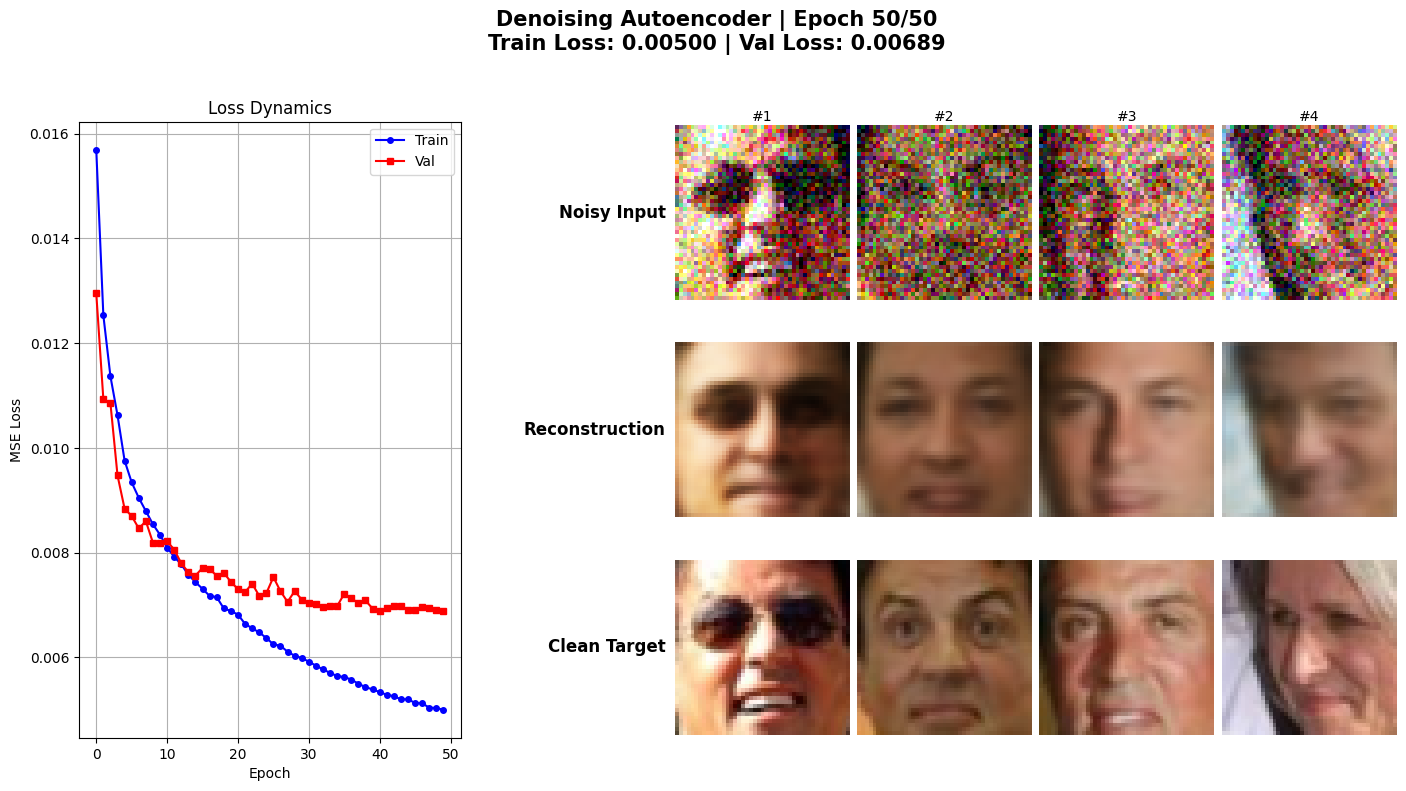

✅ Denoising Training finished!


In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

# Фиксируем зашумленные картинки для визуализации (и чистые для сравнения)
fixed_val_noisy = val_noisy_t[:4].to(device)
fixed_val_clean = val_clean_t[:4].to(device) # <-- Запомнили чистые

train_losses, val_losses = [], []
num_epochs = 50

for epoch in range(num_epochs):
    # --- TRAIN ---
    autoencoder.train()
    running_train_loss = 0.0
    for batch_noisy, batch_clean in train_loader:  # <-- Распаковываем пару
        batch_noisy = batch_noisy.to(device)
        batch_clean = batch_clean.to(device)

        optimizer.zero_grad()
        recon, _ = autoencoder(batch_noisy)  # <-- На вход даем ШУМ

        # Сравниваем результат с ЧИСТОЙ картинкой
        loss = criterion(recon, batch_clean)

        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * batch_noisy.size(0)

    train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # --- VAL ---
    autoencoder.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_noisy, batch_clean in val_loader:
            batch_noisy = batch_noisy.to(device)
            batch_clean = batch_clean.to(device)

            recon, _ = autoencoder(batch_noisy)
            loss = criterion(recon, batch_clean) # <-- Сравниваем с ЧИСТОЙ
            running_val_loss += loss.item() * batch_noisy.size(0)

    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    # --- ВИЗУАЛИЗАЦИЯ ---
    clear_output(wait=True)

    fig = plt.figure(figsize=(17, 8))
    fig.suptitle(f'Denoising Autoencoder | Epoch {epoch+1}/{num_epochs}\nTrain Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}',
                 fontsize=15, fontweight='bold', y=1.02)

    # Основная сетка: График (1) + Картинки (2)
    gs_main = fig.add_gridspec(1, 2, width_ratios=[1, 2], wspace=0.3)

    # --- График ---
    ax_loss = fig.add_subplot(gs_main[0])
    ax_loss.plot(train_losses, 'b-o', label='Train', markersize=4)
    ax_loss.plot(val_losses, 'r-s', label='Val', markersize=4)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('MSE Loss')
    ax_loss.legend()
    ax_loss.grid(True)
    ax_loss.set_title('Loss Dynamics')

    # --- Картинки ---
    # 🔑 3 строки × 5 колонок. Первая колонка узкая (0.2) под подписи, остальные под фото
    sub_gs = gs_main[1].subgridspec(3, 5, width_ratios=[0.2, 1, 1, 1, 1], wspace=0.05, hspace=0.2)

    with torch.no_grad():
        recon_fixed, _ = autoencoder(fixed_val_noisy)

    noisy_cpu = fixed_val_noisy.cpu().permute(0, 2, 3, 1).numpy()
    clean_cpu = fixed_val_clean.cpu().permute(0, 2, 3, 1).numpy()
    recon_cpu = recon_fixed.cpu().permute(0, 2, 3, 1).numpy()

    rows_data = [noisy_cpu, recon_cpu, clean_cpu]
    row_labels = ['Noisy Input', 'Reconstruction', 'Clean Target']

    for row_idx in range(3):
        for col_idx in range(5):
            ax = fig.add_subplot(sub_gs[row_idx, col_idx])

            if col_idx == 0:
                # Первая колонка: только текст подписи ряда
                ax.text(0.95, 0.5, row_labels[row_idx],
                        ha='right', va='center', fontsize=12, fontweight='bold',
                        transform=ax.transAxes)
                ax.axis('off')
            else:
                # Остальные колонки: изображения
                img_idx = col_idx - 1
                ax.imshow(np.clip(rows_data[row_idx][img_idx], 0, 1))
                ax.axis('off')
                if row_idx == 0:  # Номера примеров только у верхнего ряда
                    ax.set_title(f'#{img_idx+1}', fontsize=10, pad=3)

    # rect резервирует 5% сверху под suptitle, остальное tight_layout выровняет сам
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    display(fig)
    plt.close(fig)

print("✅ Denoising Training finished!")

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [59]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors  # LSHForest удалён из sklearn в 2019 г.
from torch.utils.data import DataLoader, TensorDataset

In [60]:
autoencoder.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [61]:
train_codes = []
with torch.no_grad():
    loader = DataLoader(TensorDataset(train_clean_t), batch_size=64, shuffle=False)
    for (batch,) in loader:
        train_codes.append(autoencoder.encoder(batch.to(device)).cpu().numpy())
train_codes = np.concatenate(train_codes)

In [62]:
nn_search = NearestNeighbors(n_neighbors=11, algorithm='auto').fit(train_codes)

In [63]:
def get_similar(image, n_neighbors=5):
    with torch.no_grad():
        # Гарантируем форму (1, C, H, W)
        if image.dim() == 3:
            image = image.unsqueeze(0)
        code = autoencoder.encoder(image.to(device)).cpu().numpy()

    # kneighbours возвращает массивы формы (1, n_neighbors)
    distances, indices = nn_search.kneighbors(code, n_neighbors=n_neighbors)

    # Исправляем unpacking: берём первые строки массивов
    return distances[0], train_clean_t[indices[0]]

In [68]:
def show_similar(image):
    distances, neighbors = get_similar(image, n_neighbors=11)

    plt.figure(figsize=(16, 6))

    # Оригинал
    plt.subplot(3, 4, 1)
    plt.imshow(image.squeeze().permute(1, 2, 0).cpu().numpy())
    plt.title("Original", fontsize=11, fontweight='bold')
    plt.axis('off')

    # Ближайшие соседи
    for i in range(11):
        plt.subplot(3, 4, i+2)
        plt.imshow(neighbors[i].permute(1, 2, 0).cpu().numpy())
        plt.title(f"Dist={distances[i]:.3f}", fontsize=9)
        plt.axis('off')

    plt.suptitle("Most Similar Faces in Latent Space", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

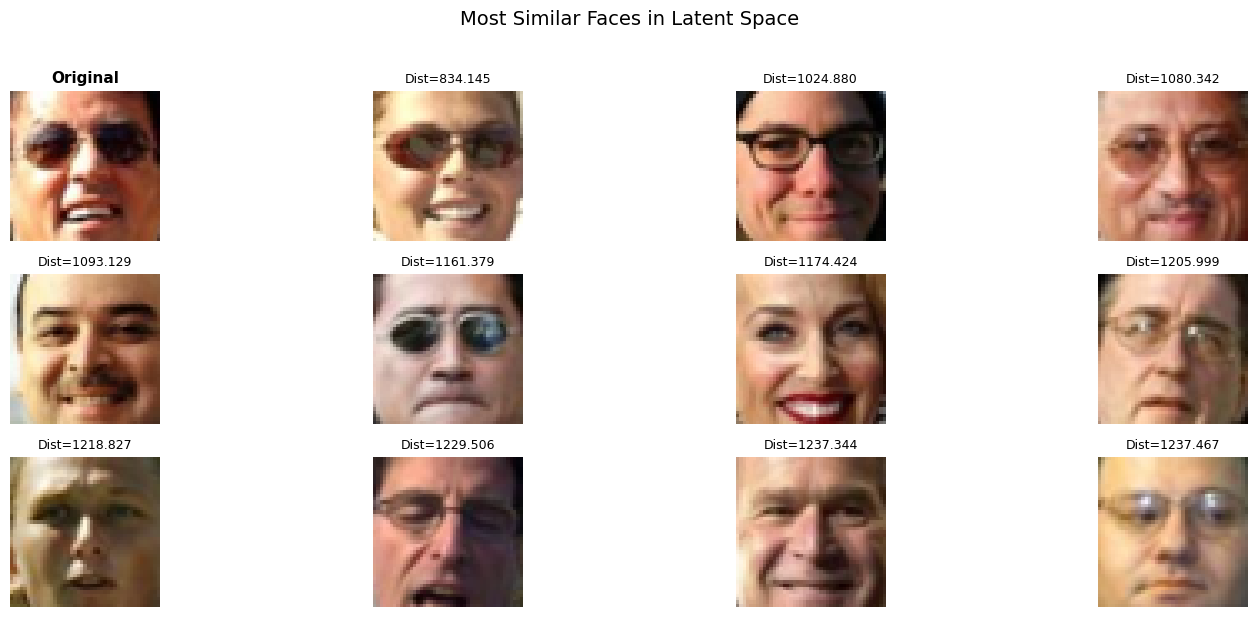

In [69]:
show_similar(val_clean_t[0])

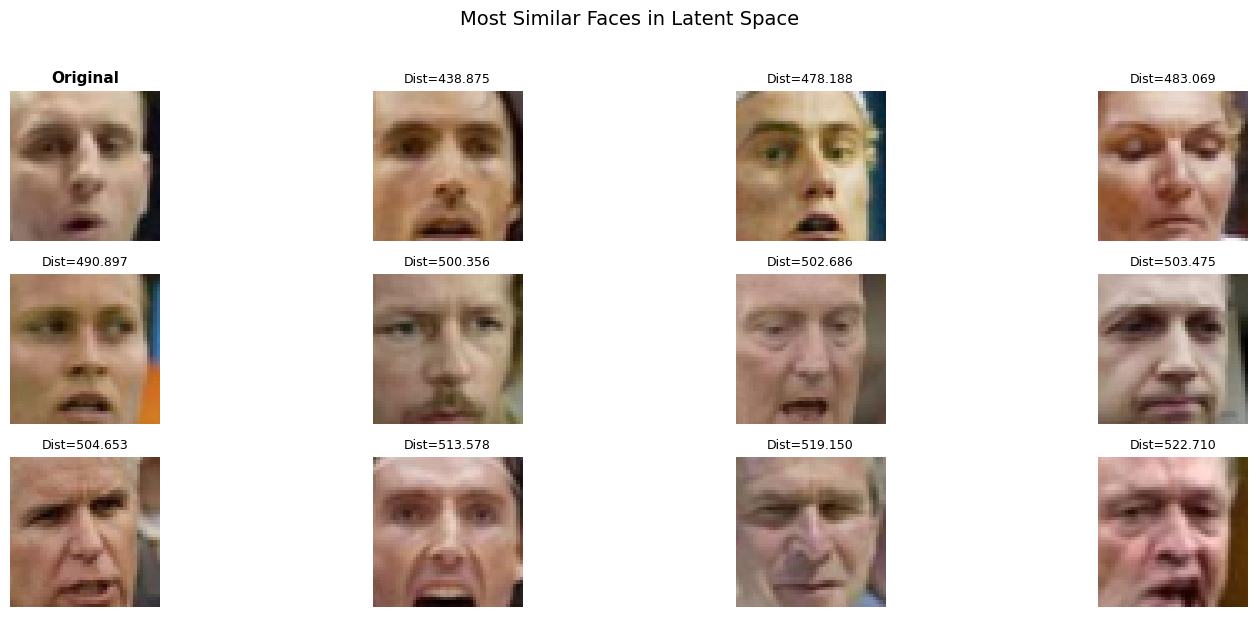

In [70]:
show_similar(val_clean_t[-1])